# Salary Intelligence - Neural Network MLP Regressor

This notebook trains a custom Multi-Layer Perceptron (MLP) regressor to forecast software engineering salaries based on role, location, seniority, and years of experience. The model is built using TensorFlow and Keras, evaluated, and saved for integration into the PlacementOS backend.

In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras
from tensorflow.keras import layers

sns.set_theme(style="whitegrid")

C:\Users\Vansh Agrawal\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


## 1. Load and Explore Dataset

In [2]:
data_path = "../data/india_salary_raw.json"
with open(data_path, "r", encoding="utf-8") as f:
    raw_data = json.load(f)

df = pd.DataFrame(raw_data)
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (200, 5)


,role,location,seniority,years_experience,salary
0,Data Scientist,Bangalore,Mid,6,458522
1,Data Scientist,Bangalore,Junior,3,1478550
2,Software Engineer,Hyderabad,Junior,7,1313336
3,Data Scientist,Bangalore,Mid,0,426567
4,Product Manager,Delhi,Junior,6,2398497


## 2. Preprocessing & Feature Engineering

We will one-hot encode the categorical variables (`role`, `location`, `seniority`) and keep track of the columns so that our backend can replicate the exact feature mapping during inference.

In [3]:
# Keep copy of original features
categorical_cols = ["role", "location", "seniority"]
numerical_cols = ["years_experience"]

# Perform one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=False)

# Isolate features (X) and target variable (y)
X = df_encoded.drop(columns=["salary"])
y = df_encoded["salary"].values.astype("float32")

# Save feature column layout for backend inference
feature_columns = list(X.columns)
os.makedirs("../models", exist_ok=True)
with open("../models/salary_features.json", "w") as f:
    json.dump(feature_columns, f, indent=4)

print(f"Total features encoded: {len(feature_columns)}")
print(f"Feature columns: {feature_columns[:10]}...")

Total features encoded: 14
Feature columns: ['years_experience', 'role_Data Scientist', 'role_DevOps Engineer', 'role_Product Manager', 'role_Software Engineer', 'location_Bangalore', 'location_Chennai', 'location_Delhi', 'location_Hyderabad', 'location_Mumbai']...


## 3. Build Keras MLP Model

In [4]:
def build_model(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.15),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.1),
        layers.Dense(32, activation="relu"),
        layers.Dense(1) # Linear output for regression
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.002),
        loss="mse",
        metrics=["mae"]
    )
    return model

model = build_model(len(feature_columns))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Model Training

In [5]:
history = model.fit(
    X.values.astype("float32"),
    y,
    epochs=50,
    batch_size=16,
    validation_split=0.15,
    verbose=1
)

Epoch 1/50


 1/11 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - loss: 2266013892608.0000 - mae: 1359517.7500

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 3169355563008.0000 - mae: 1583522.1250 - val_loss: 2750078255104.0000 - val_mae: 1495389.3750


Epoch 2/50


 1/11 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 3038368759808.0000 - mae: 1554992.6250

...

 1/11 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 877241827328.0000 - mae: 806817.8750

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 839343669248.0000 - mae: 772886.3125 - val_loss: 646733561856.0000 - val_mae: 651790.1250


Epoch 50/50


 1/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 741766135808.0000 - mae: 752054.6250

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 847477997568.0000 - mae: 775009.4375 - val_loss: 644399366144.0000 - val_mae: 651068.7500


## 5. Evaluate and Visualize Performance

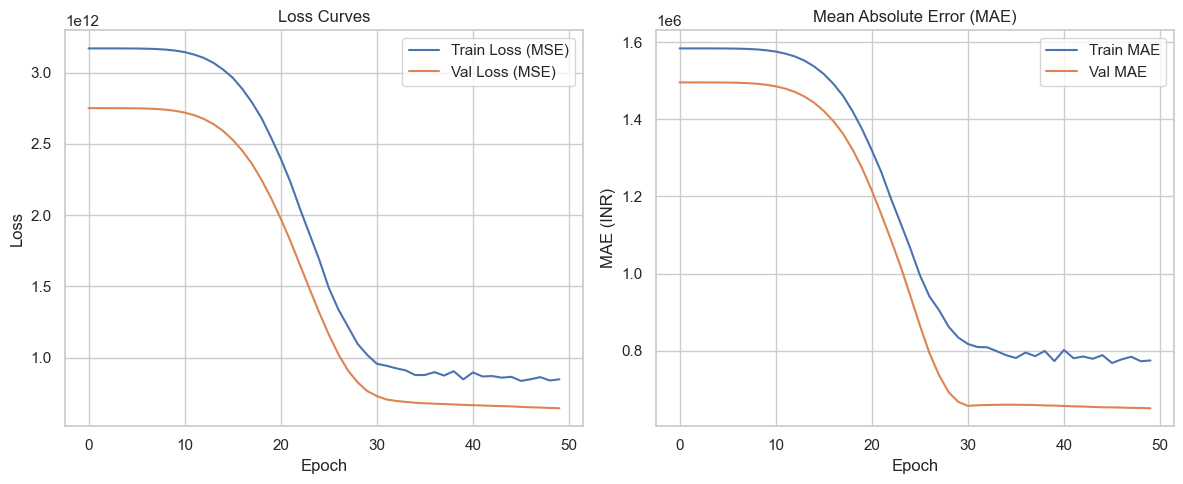

In [6]:
# Plot training & validation loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train Loss (MSE)")
plt.plot(history.history["val_loss"], label="Val Loss (MSE)")
plt.title("Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["mae"], label="Train MAE")
plt.plot(history.history["val_mae"], label="Val MAE")
plt.title("Mean Absolute Error (MAE)")
plt.xlabel("Epoch")
plt.ylabel("MAE (INR)")
plt.legend()

plt.tight_layout()
plt.savefig("../models/salary_training_curves.png")
plt.show()

## 6. Save Model

In [7]:
model.save("../models/salary_india_dl_model.h5")
print("Model saved successfully to ../models/salary_india_dl_model.h5")

Model saved successfully to ../models/salary_india_dl_model.h5
